In [79]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy as sp
import seaborn as sns
import xarray as xr

In [17]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [18]:
N = 20
K = 30

alpha = 10.0
P0 = sp.stats.norm

In [19]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
# print(np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1))
# w = w/np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)


omega = P0.rvs(size=(N, K))

x_plot = xr.DataArray(np.linspace(-3, 3, 200), dims=["plot"])

sample_cdfs = (w[..., np.newaxis] * np.less.outer(omega, x_plot.values)).sum(axis=1)

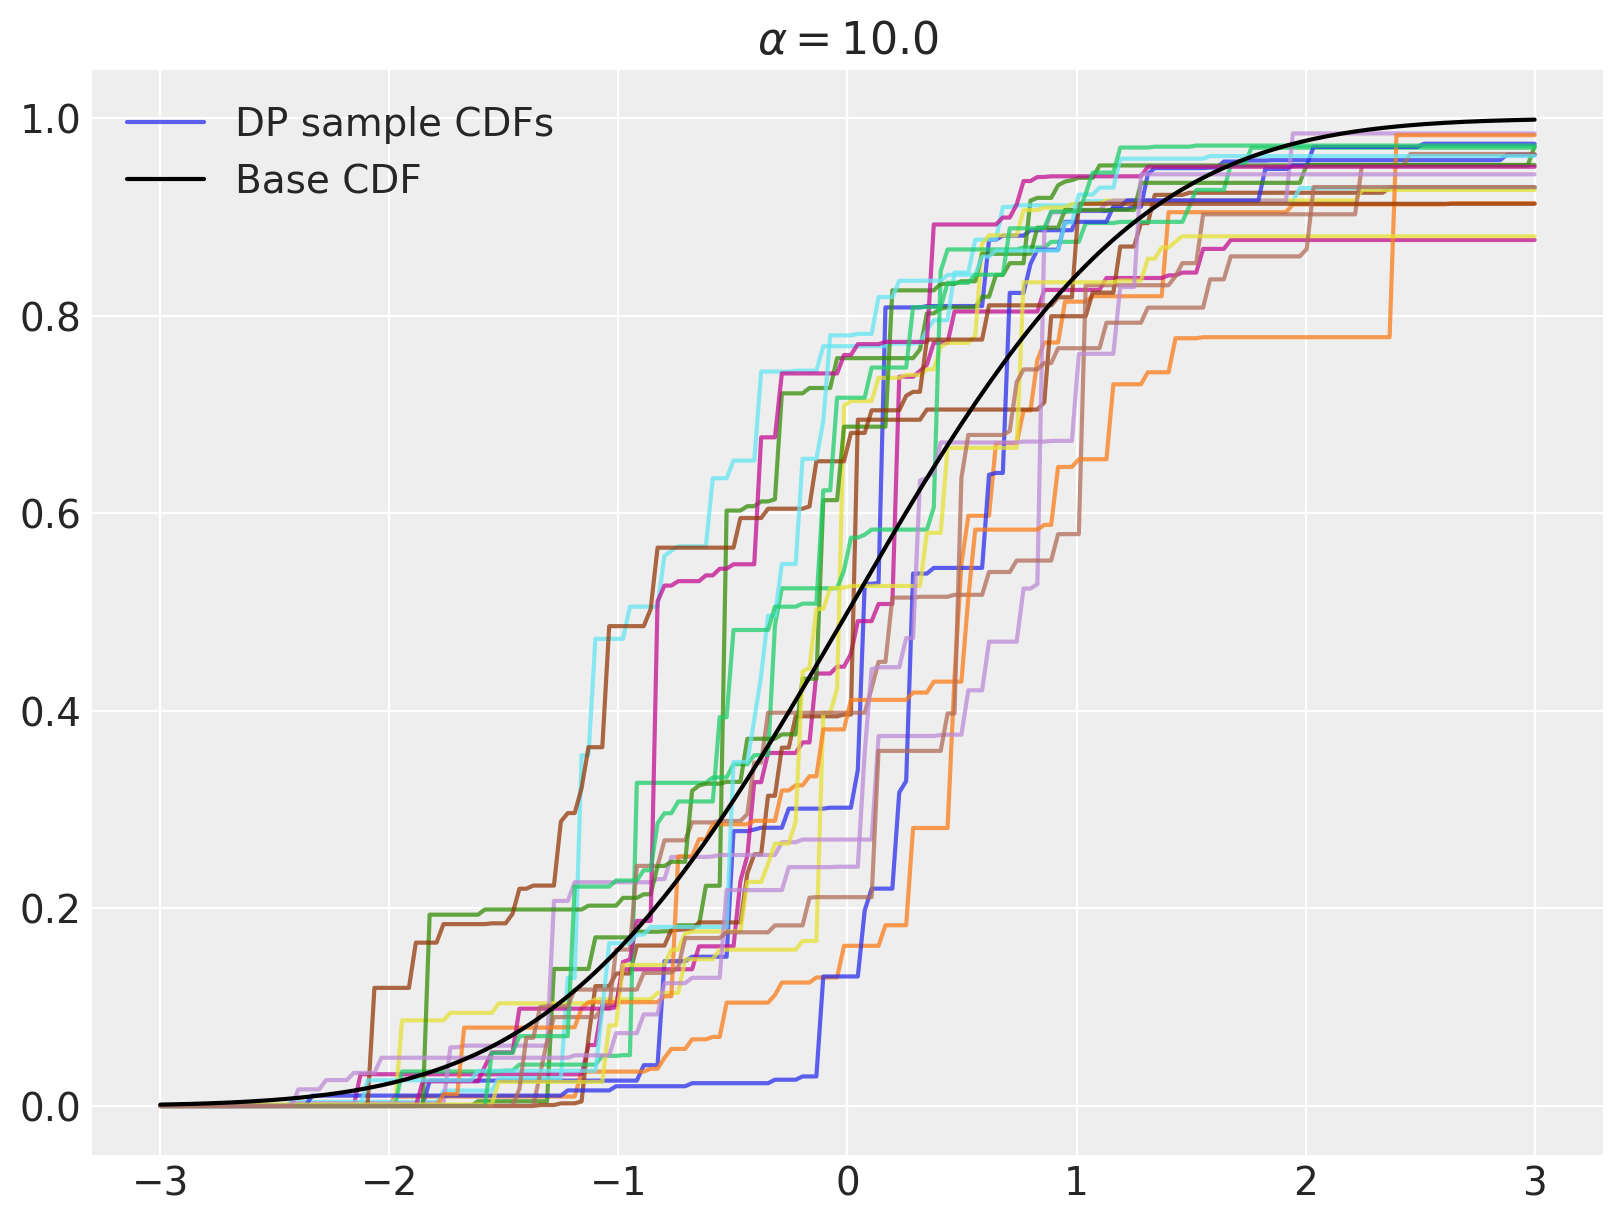

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, sample_cdfs[0], alpha=0.75, label="DP sample CDFs")
ax.plot(x_plot, sample_cdfs[1:].T, alpha=0.75)
ax.plot(x_plot, P0.cdf(x_plot), c="k", label="Base CDF")

ax.set_title(rf"$\alpha = {alpha}$")
ax.legend(loc=2);

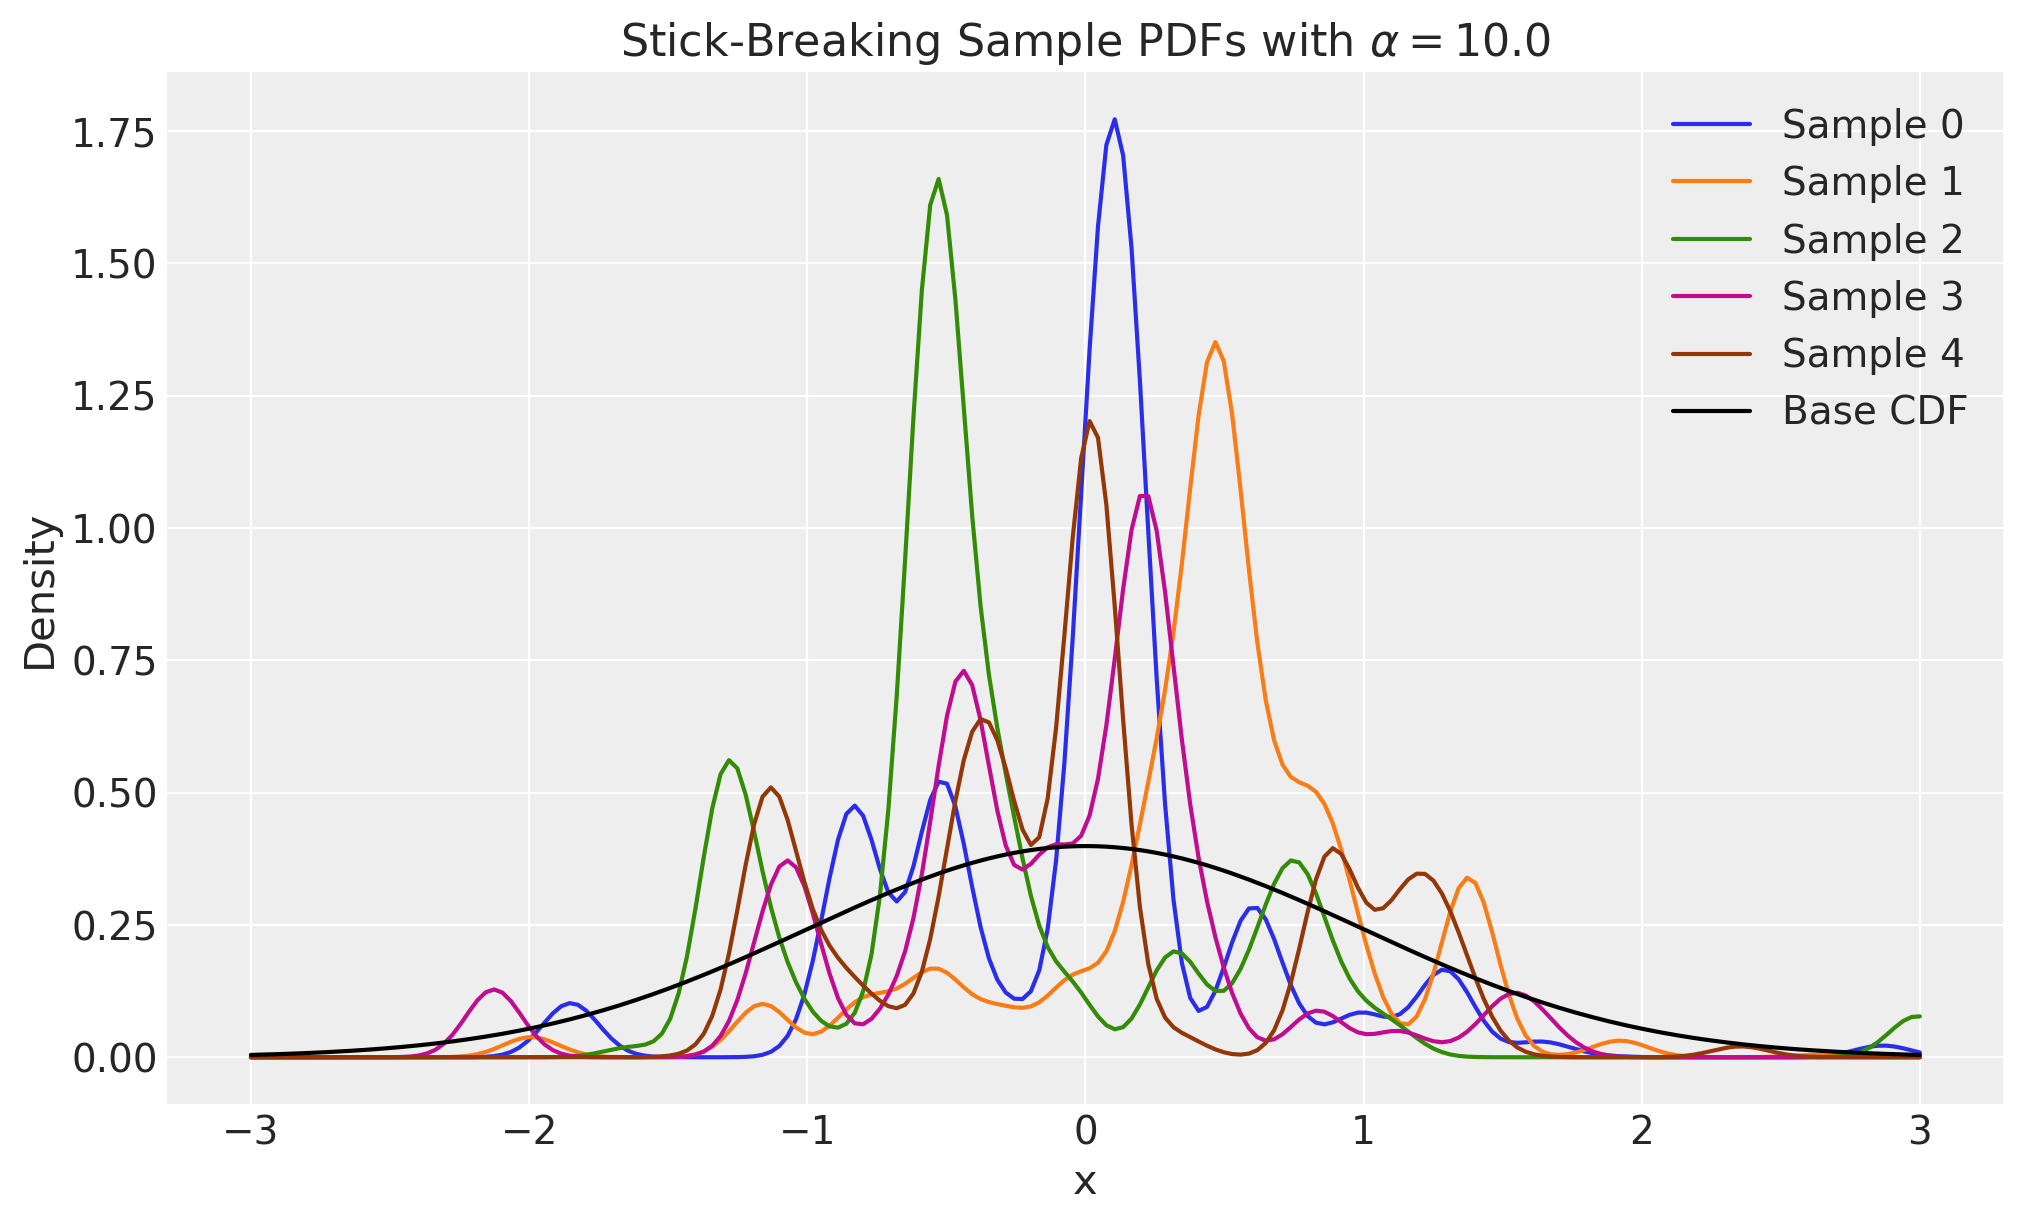

In [21]:
# Bandwidth for smoothing (adjust if needed)
bandwidth = 0.1

# Precompute the normal PDFs centered at each omega
pdfs = P0.pdf(x_plot.values[None, None, :], loc=omega[:, :, None], scale=bandwidth)

# Weighted sum over atoms for each sample
sample_pdfs = (w[..., None] * pdfs).sum(axis=1)

# Plot a few samples
plt.figure(figsize=(10, 6))
for i in range(min(5, N)):
    plt.plot(x_plot, sample_pdfs[i], label=f"Sample {i}")
plt.plot(x_plot, P0.pdf(x_plot), c="k", label="Base CDF")
plt.title(rf"Stick-Breaking Sample PDFs with $\alpha = {alpha}$")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


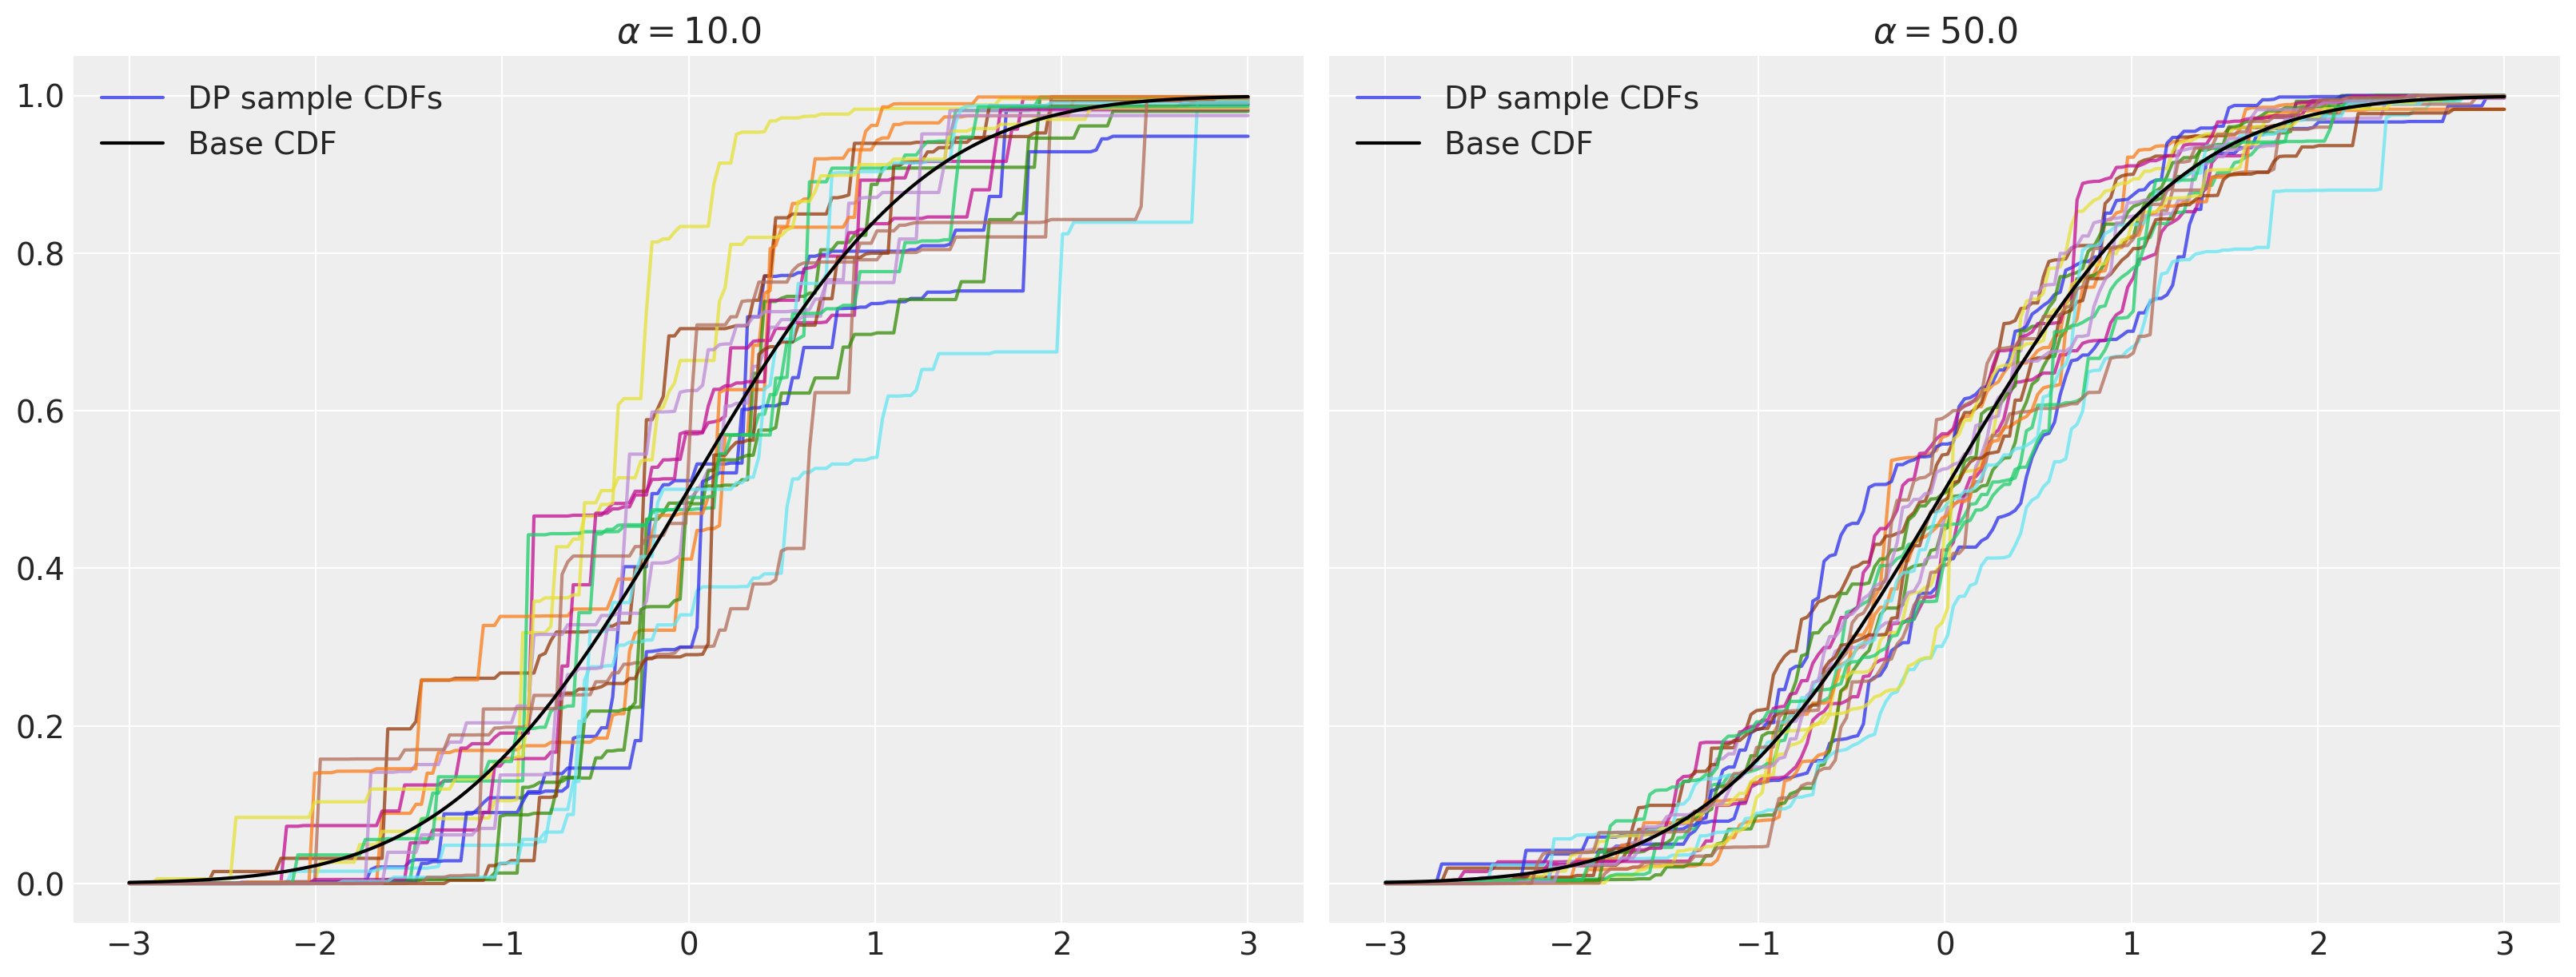

In [22]:
fig, (l_ax, r_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 6))

K = 50
alpha = 10.0

beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
# w = w / np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)

omega = P0.rvs(size=(N, K))

sample_cdfs = (w[..., np.newaxis] * np.less.outer(omega, x_plot.values)).sum(axis=1)

l_ax.plot(x_plot, sample_cdfs[0], alpha=0.75, label="DP sample CDFs")
l_ax.plot(x_plot, sample_cdfs[1:].T, alpha=0.75)
l_ax.plot(x_plot, P0.cdf(x_plot), c="k", label="Base CDF")

l_ax.set_title(rf"$\alpha = {alpha}$")
l_ax.legend(loc=2)

K = 200
alpha = 50.0

beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
w = w / np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)

omega = P0.rvs(size=(N, K))

sample_cdfs = (w[..., np.newaxis] * np.less.outer(omega, x_plot.values)).sum(axis=1)

r_ax.plot(x_plot, sample_cdfs[0], alpha=0.75, label="DP sample CDFs")
r_ax.plot(x_plot, sample_cdfs[1:].T, alpha=0.75)
r_ax.plot(x_plot, P0.cdf(x_plot), c="k", label="Base CDF")

r_ax.set_title(rf"$\alpha = {alpha}$")
r_ax.legend(loc=2);

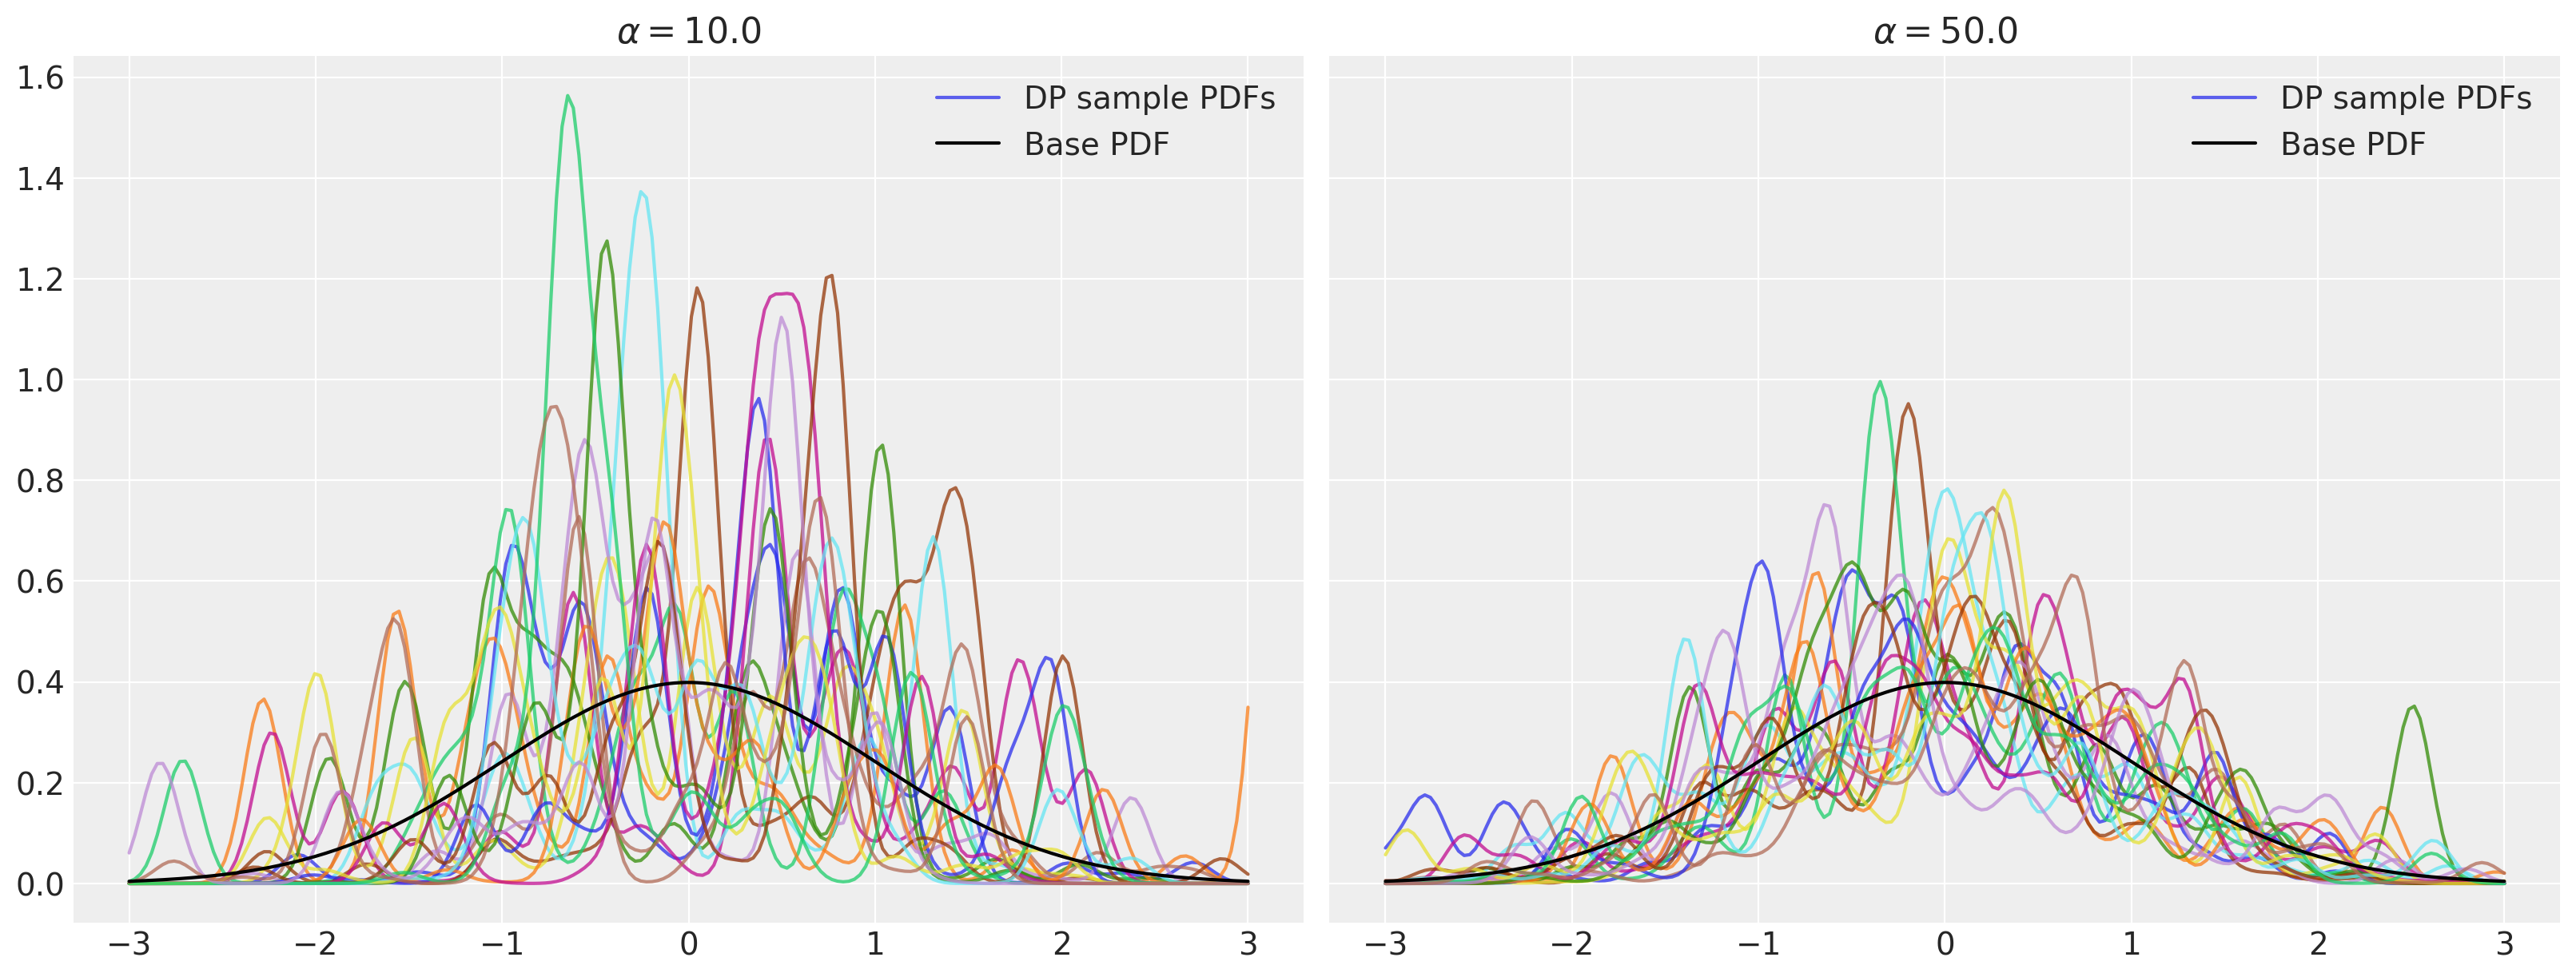

In [23]:
# Parameters
bandwidth = 0.1  # smoothing bandwidth

fig, (l_ax, r_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 6))

# --- Left Plot: alpha = 10, K = 50 ---
K = 50
alpha = 10.0

# Stick-breaking weights
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
# w = w / np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)

# Atom locations
omega = P0.rvs(size=(N, K))

# Smoothed PDFs using Gaussian kernel
pdfs = sp.stats.norm.pdf(x_plot.values[None, None, :], loc=omega[:, :, None], scale=bandwidth)
sample_pdfs = (w[..., None] * pdfs).sum(axis=1)

# Plot
l_ax.plot(x_plot, sample_pdfs[0], alpha=0.75, label="DP sample PDFs")
l_ax.plot(x_plot, sample_pdfs[1:].T, alpha=0.75)
l_ax.plot(x_plot, P0.pdf(x_plot), c="k", label="Base PDF")
l_ax.set_title(rf"$\alpha = {alpha}$")
l_ax.legend(loc="upper right")

# --- Right Plot: alpha = 50, K = 200 ---
K = 200
alpha = 50.0

beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)

omega = P0.rvs(size=(N, K))

pdfs = sp.stats.norm.pdf(x_plot.values[None, None, :], loc=omega[:, :, None], scale=bandwidth)
sample_pdfs = (w[..., None] * pdfs).sum(axis=1)

r_ax.plot(x_plot, sample_pdfs[0], alpha=0.75, label="DP sample PDFs")
r_ax.plot(x_plot, sample_pdfs[1:].T, alpha=0.75)
r_ax.plot(x_plot, P0.pdf(x_plot), c="k", label="Base PDF")
r_ax.set_title(rf"$\alpha = {alpha}$")
r_ax.legend(loc="upper right")

plt.show()


In [24]:
N = 5
K = 30

alpha = 2
P0 = sp.stats.norm
f = lambda x, theta: sp.stats.norm.pdf(x, theta, 0.3)

In [25]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
# w = w/np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)

theta = P0.rvs(size=(N, K))

dpm_pdf_components = f(x_plot, theta[..., np.newaxis])
dpm_pdfs = (w[..., np.newaxis] * dpm_pdf_components).sum(axis=1)

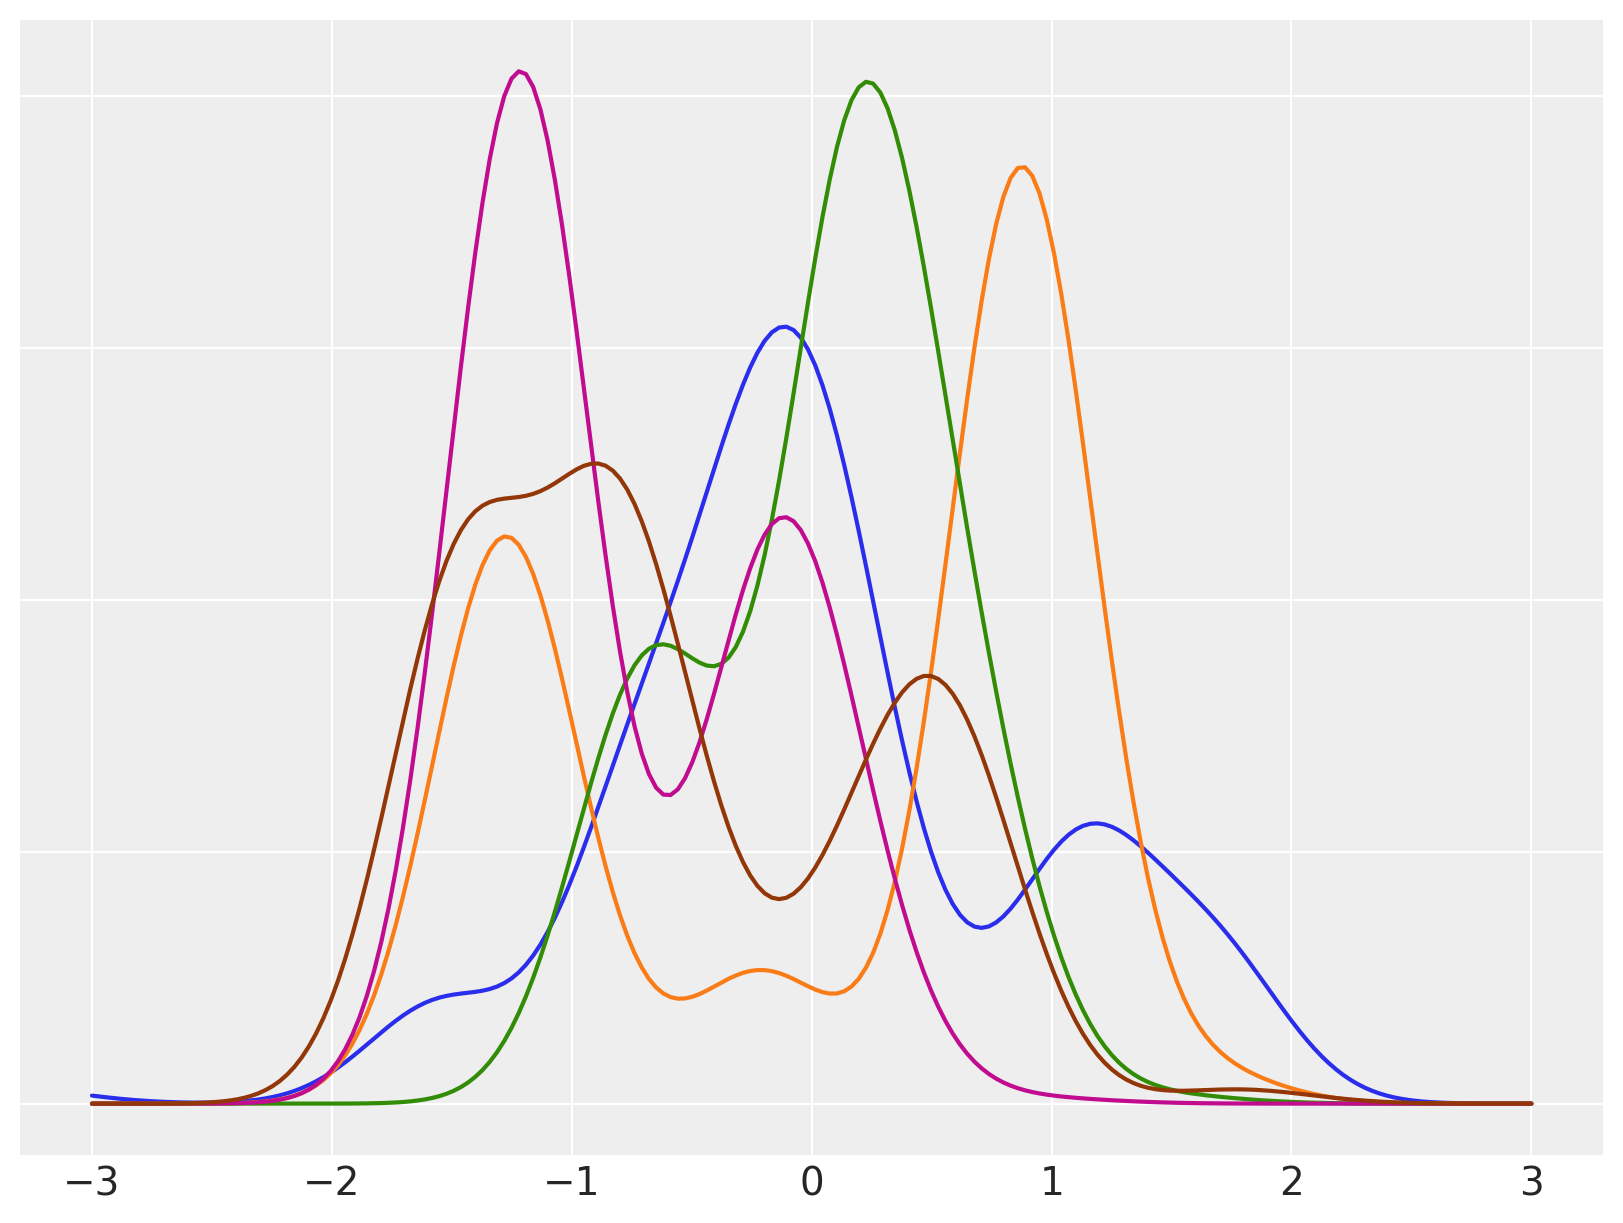

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, dpm_pdfs.T)

ax.set_yticklabels([]);


In [27]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
# w = w / np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)

w_prime = 1 - w.cumsum(axis=1)
alpha_1 = 2
beta_1 = sp.stats.beta.rvs(alpha_1*w, alpha_1*w_prime, size=(N, K))
w_1 = np.empty_like(beta_1)
w_1[:, 0] = beta_1[:, 0]
w_1[:, 1:] = beta_1[:, 1:] * (1 - beta_1[:, :-1]).cumprod(axis=1)
dpm_pdfs_1 = (w_1[..., np.newaxis] * dpm_pdf_components).sum(axis=1)


In [28]:
def stick_breaking_constructor(alpha: float, cat_upbd: int, sample_size: int=1, base_dist:np.array=None) -> np.array:
    if base_dist is None:
        # Construct Dirichlet Process
        beta = sp.stats.beta.rvs(1, alpha, size=(sample_size, cat_upbd))
    else:
        # Construct next level Dirichlet Process in Hierarchical Dirichlet Process
        base_prime = 1 - base_dist.cumsum(axis=1)
        beta = sp.stats.beta.rvs(alpha*base_dist, alpha*base_prime, size=(sample_size, cat_upbd))
    w = np.empty_like(beta)
    w[:, 0] = beta[:, 0]
    w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)  
    # w = w / np.sum(w, axis=tuple(range(1, w.ndim))).reshape(-1, 1)
    return w    

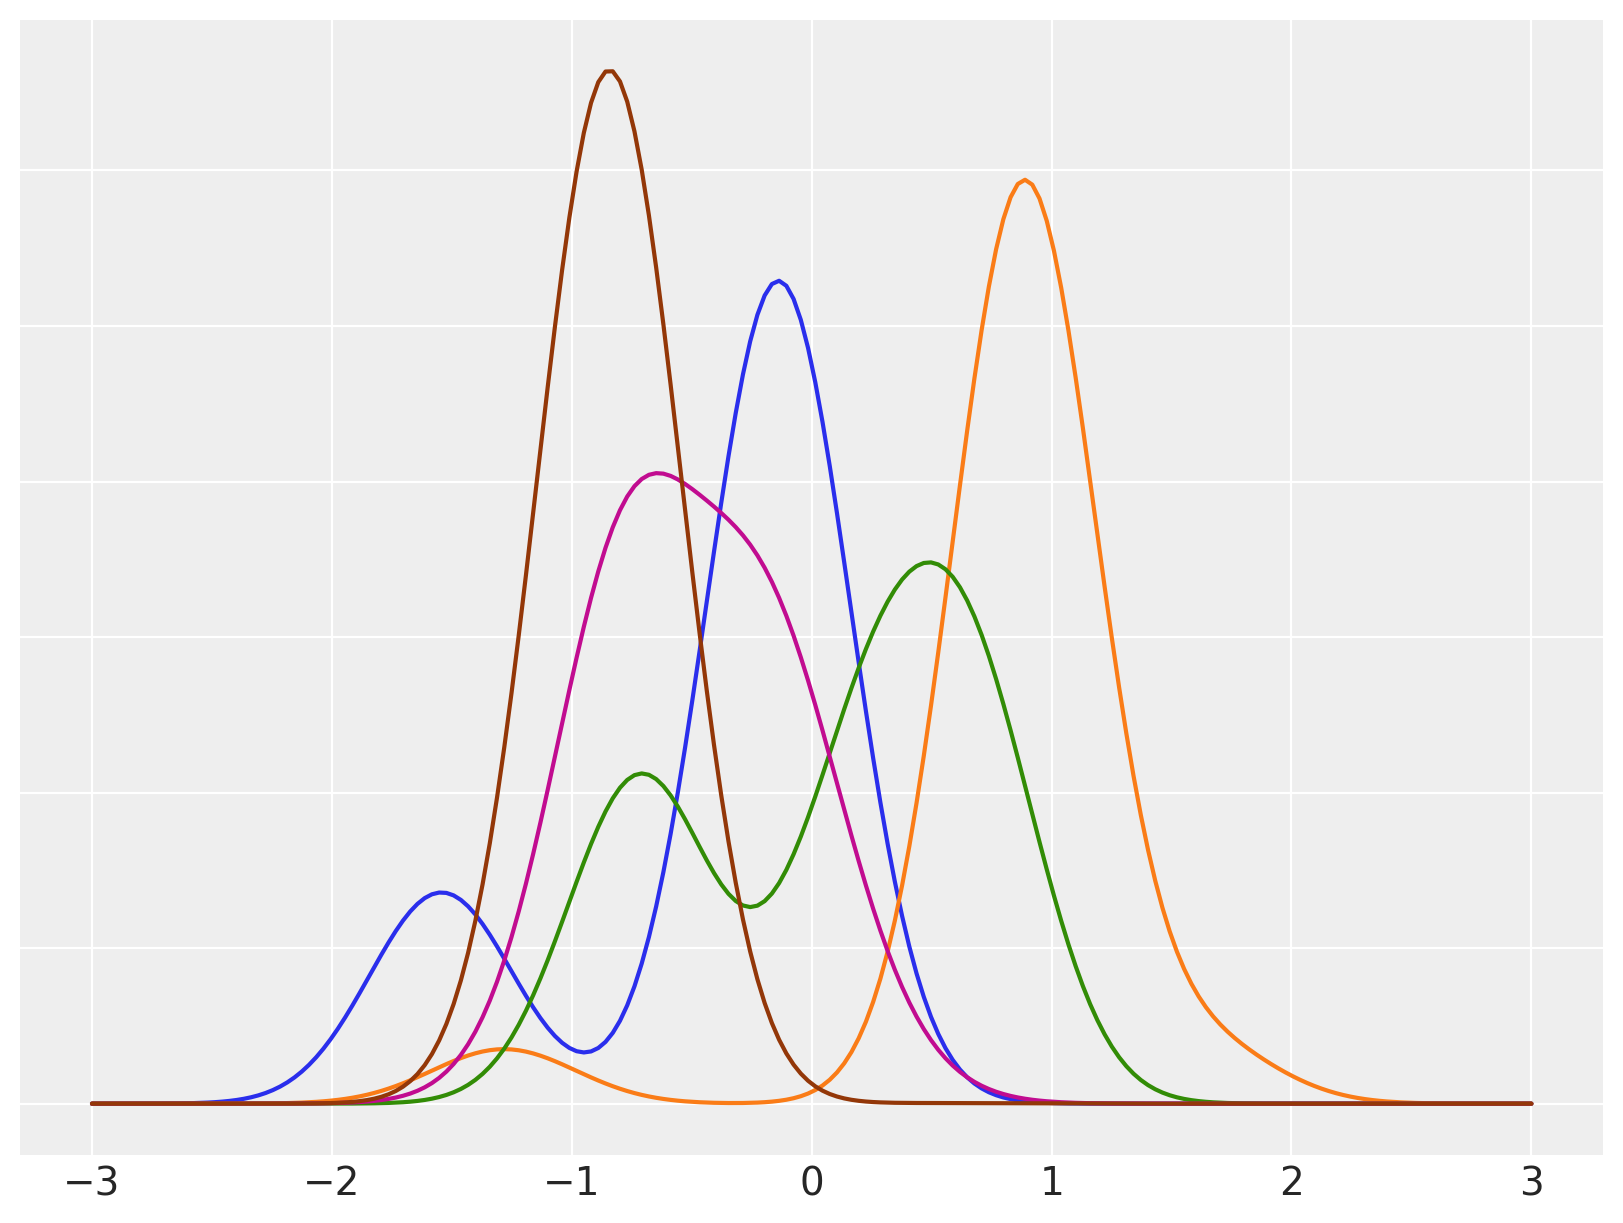

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, dpm_pdfs_1.T)

ax.set_yticklabels([]);

In [31]:
def nCRP_constructor(depth: int, cat_upb: int, alpha: int) -> np.array:
    dims = [cat_upb + 1]*depth
    weights = {}
    w = stick_breaking_constructor(alpha, cat_upb)
    weights["Level_0"] = w
    for d in range(depth):
        level = []
        k = np.power(cat_upb, d+1)
        for i in range(k):
            w = stick_breaking_constructor(alpha, cat_upb)
            level.append(w)
        weights[f"Level_{d+1}"] = np.vstack(level)
    return weights


In [32]:
def combine_hierarchical_log_probs(level_probs, k):
    d = len(level_probs)
    prob_values = list(level_probs.values())
    # Start with full joint probabilities as ones
    log_joint = np.zeros([1])
    
    for i in range(d):
        log_T = np.log(prob_values[i])  # shape: (k^i, k)
        
        # Reshape joint to match number of parents
        log_joint = log_joint.reshape(-1, 1)  # shape: (k^i, 1)

        # Multiply element-wise with conditional probs
        log_joint = log_joint + log_T  # shape: (k^i, k)

    # Reshape final joint to (k, k, ..., k) with d dimensions
    return log_joint.reshape([k] * d)

In [33]:
weights = nCRP_constructor(2, 2, 2)
print(weights)
combined_w = combine_hierarchical_log_probs(weights, 2)
print(np.exp(combined_w))
print(np.sum(np.exp(combined_w), axis=(1, 2)))

{'Level_0': array([[0.0486231, 0.2284955]]), 'Level_1': array([[0.49190778, 0.32153589],
       [0.77545859, 0.0818233 ]]), 'Level_2': array([[0.46115633, 0.10016655],
       [0.31304517, 0.36063464],
       [0.12085463, 0.04860319],
       [0.36251554, 0.05295896]])}
[[[0.01102997 0.00239579]
  [0.00489417 0.00563819]]

 [[0.02141409 0.00861194]
  [0.00677768 0.00099013]]]
[0.02395813 0.03779385]


In [34]:
def get_joint_prob(level_probs, cat_path, k):
    prob_values = list(level_probs.values())
    prob = 1.0
    index = 0  # will be used to index into conditional rows

    for i, cat in enumerate(cat_path):
        T = prob_values[i]  # shape: (k^i, k)
        prob *= T[index, cat]
        index = index * k + cat  # update parent index for next level

    return prob

In [35]:
get_joint_prob(weights, [0, 1, 1], 2)

0.005638187836215731

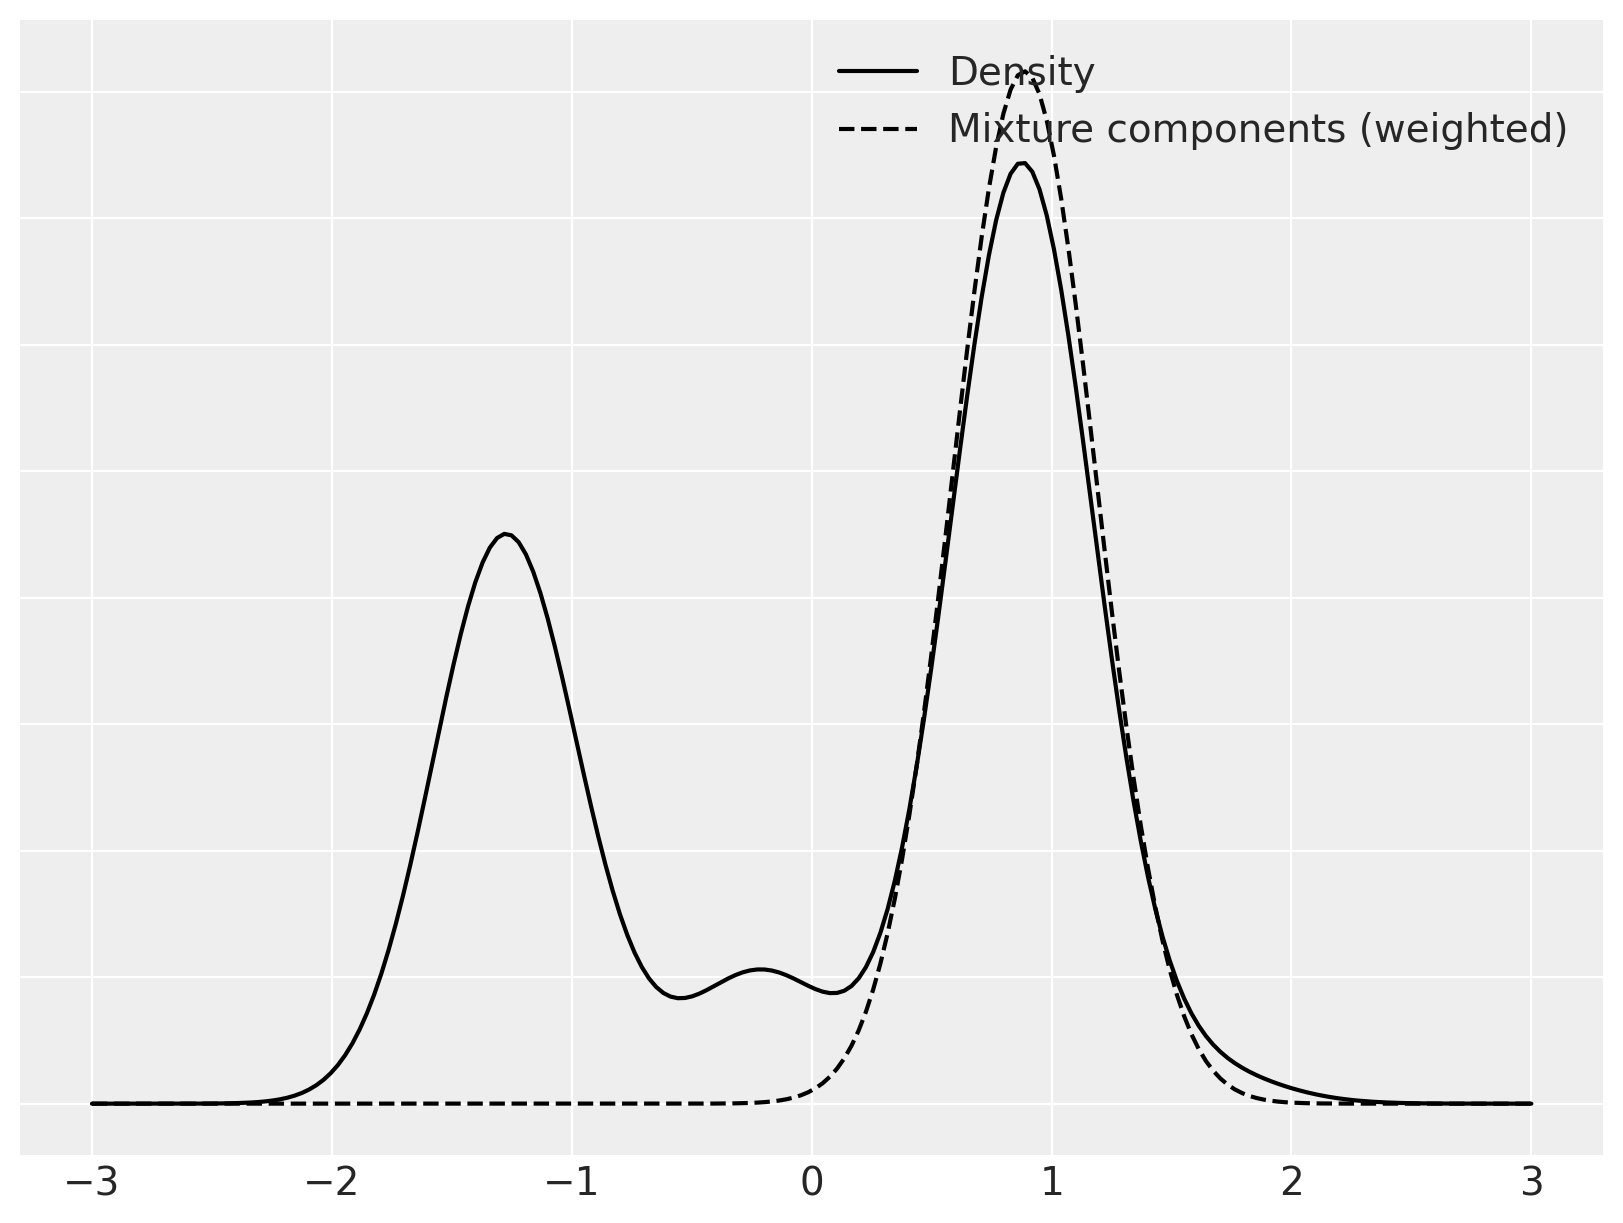

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

ix = 1

ax.plot(x_plot, dpm_pdfs[ix], c="k", label="Density")
ax.plot(
    x_plot,
    (w[..., np.newaxis] * dpm_pdf_components)[ix, 0],
    "--",
    c="k",
    label="Mixture components (weighted)",
)
ax.plot(x_plot, (w[..., np.newaxis] * dpm_pdf_components)[ix].T, "--", c="k")

ax.set_yticklabels([])
ax.legend(loc=1);

In [42]:
(w[..., np.newaxis] * dpm_pdf_components)[ix].shape

(30, 200)

In [43]:
x_plot.shape

(200,)

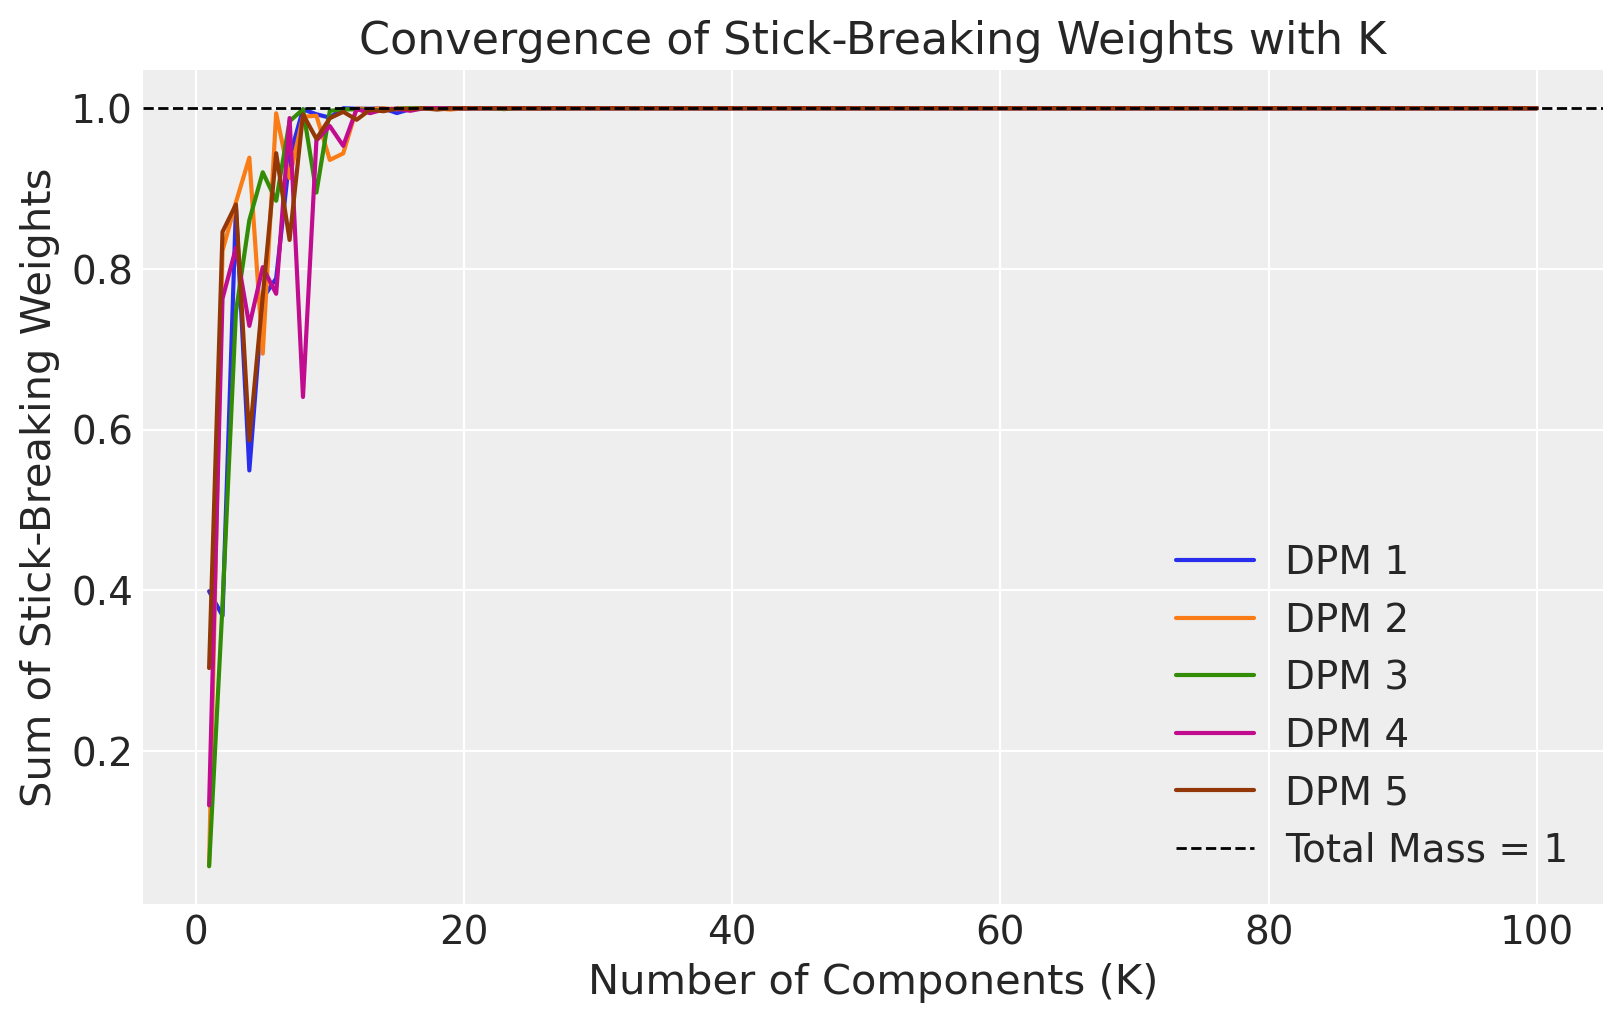

In [48]:
N = 5        # Number of DPM instances
alpha = 2    # Concentration parameter

w_sum = []

for K in range(1, 101):
    beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
    w = np.empty_like(beta)
    w[:, 0] = beta[:, 0]
    w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)
    w_sum.append(np.sum(w, axis=1))  # shape (N,)

w_sum = np.array(w_sum)  # shape (100, N)

# Plot each DPM instance's cumulative weight sum
plt.figure(figsize=(8, 5))
for i in range(N):
    plt.plot(range(1, 101), w_sum[:, i], label=f'DPM {i+1}')

plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Total Mass = 1')
plt.xlabel('Number of Components (K)')
plt.ylabel('Sum of Stick-Breaking Weights')
plt.title('Convergence of Stick-Breaking Weights with K')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
try:
    old_faithful_df = pd.read_csv(os.path.join("..", "data", "old_faithful.csv"))
except FileNotFoundError:
    old_faithful_df = pd.read_csv(pm.get_data("old_faithful.csv"))

In [50]:
old_faithful_df["std_waiting"] = (
    old_faithful_df.waiting - old_faithful_df.waiting.mean()
) / old_faithful_df.waiting.std()

In [51]:
old_faithful_df.head()

,eruptions,waiting,std_waiting
0,3.600,79,0.596025
1,1.800,54,-1.242890
2,3.333,74,0.228242
3,2.283,62,-0.654437
4,4.533,85,1.037364


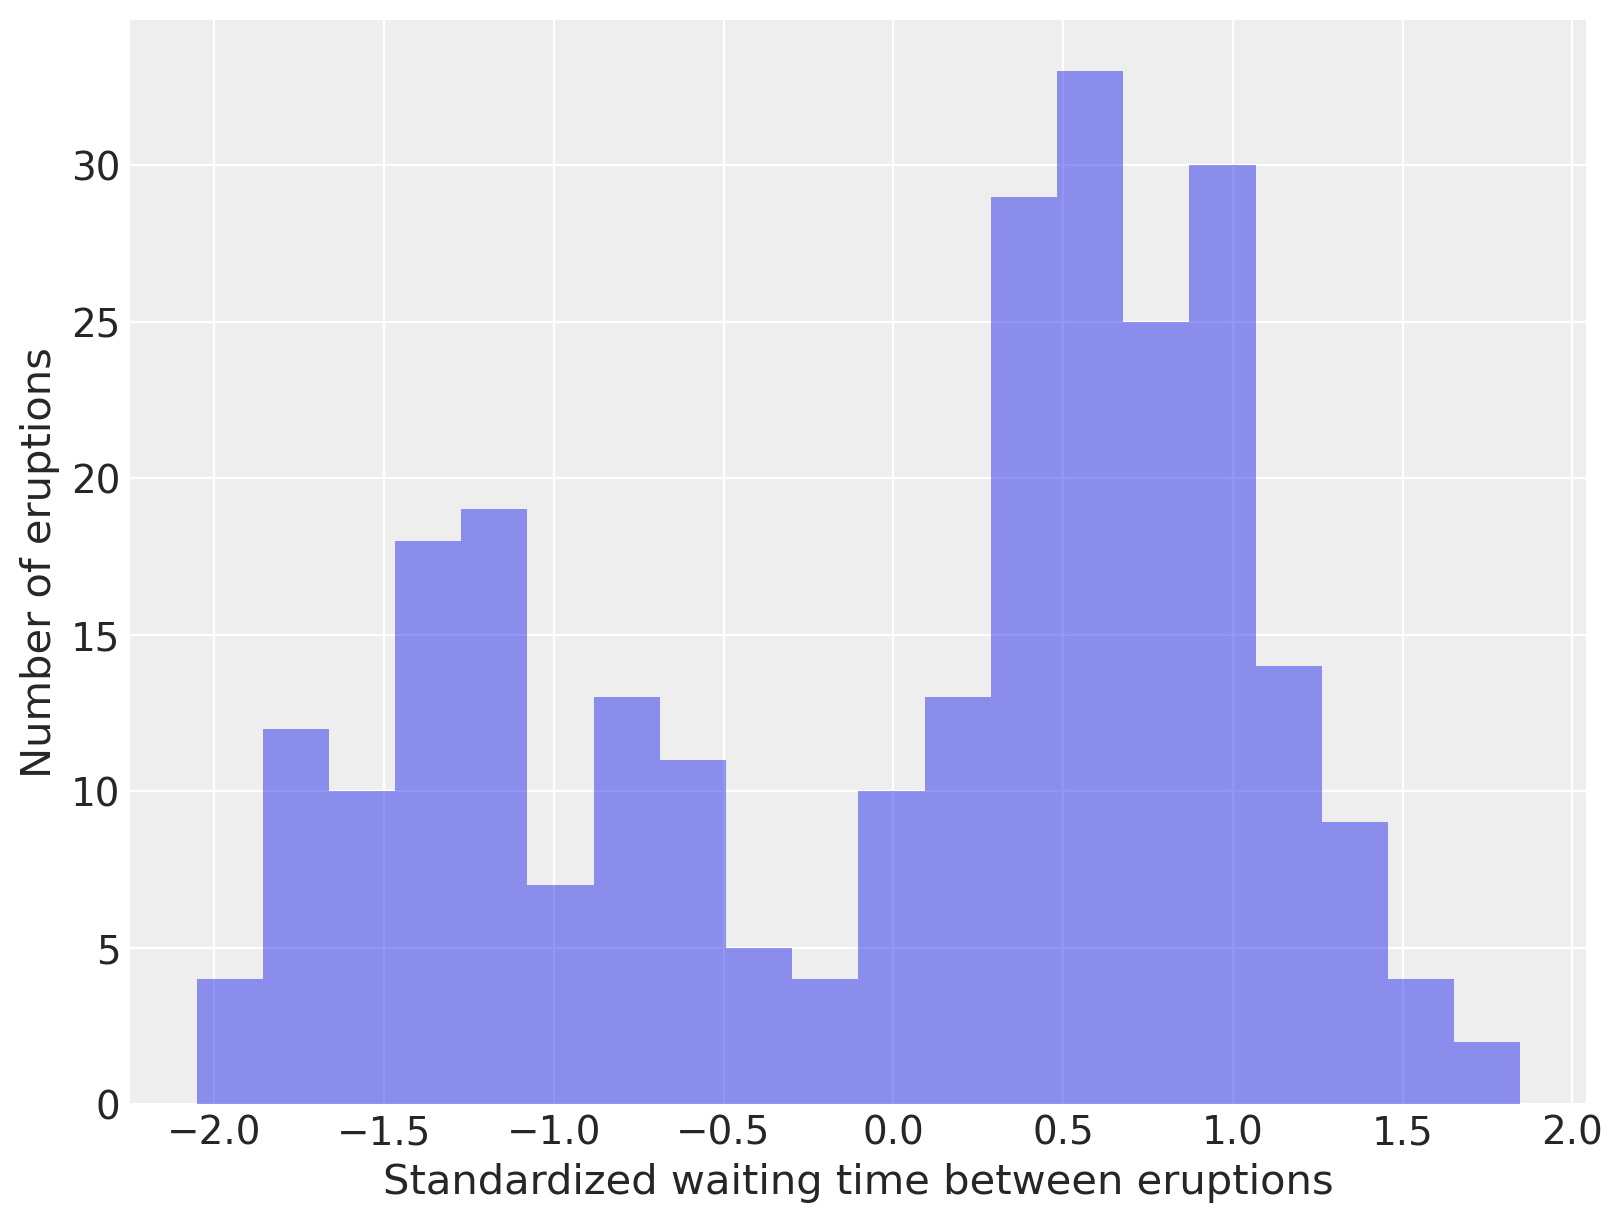

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting, bins=n_bins, color="C0", lw=0, alpha=0.5)

ax.set_xlabel("Standardized waiting time between eruptions")
ax.set_ylabel("Number of eruptions");

In [71]:
N = old_faithful_df.shape[0]
K = 60

In [86]:
def stick_breaking(beta):
    # Compute the remaining portion of the stick
    portion_remaining = pt.concatenate([[1], pt.extra_ops.cumprod(1 - beta)[:-1]])

    # Compute the stick-breaking weights
    weights = beta * portion_remaining

    # Check if the weights are in the range [0, 1] using symbolic conditions
    if pt.any(weights < 0).eval() or pt.any(weights > 1).eval():
        raise ValueError("Some weights are out of the range [0, 1]")

    # Check if the sum of weights is close to 1
    weight_sum = weights.sum()
    if not pt.isclose(weight_sum, 1.0).eval():
        # Normalize the weights to sum to 1 if the sum is not exactly 1
        weights = weights / weight_sum
        print(f"Warning: The sum of weights was {weight_sum.eval()}, but has been normalized to 1.")

    return weights

In [91]:
with pm.Model(coords={"component": np.arange(K), "obs_id": np.arange(N)}) as model:
    # Hierarchical Dirichlet Process with depth 1
    # level 0
    alpha_0 = pm.Gamma("alpha_0", 1.0, 1.0)
    beta_0 = pm.Beta("beta_0", 1.0, alpha_0, dims="component")
    # level 1
    alpha = pm.Gamma("alpha", 1.0, 1.0)
    beta = pm.Beta("beta", alpha*beta_0, alpha*pt.extra_ops.cumsum(1 - beta_0), dims="component")
    # mixture weights
    w = pm.Deterministic("w", stick_breaking(beta), dims="component")
    # mixture components
    tau = pm.Gamma("tau", 1.0, 1.0, dims="component")
    lambda_ = pm.Gamma("lambda_", 10.0, 1.0, dims="component")
    mu = pm.Normal("mu", 0, tau=lambda_ * tau, dims="component")
    # mixture model
    obs = pm.NormalMixture(
        "obs", w, mu, tau=lambda_ * tau, observed=old_faithful_df.std_waiting.values, dims="obs_id"
    )

In [92]:
with model:
    trace = pm.sample(
        tune=2500,
        init="advi",
        target_accept=0.975,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using advi...


Output()

Convergence achieved at 62500
Interrupted at 62,499 [31%]: Average Loss = 436.82
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_0, beta_0, alpha, beta, tau, lambda_, mu]


Output()

Sampling 4 chains for 2_500 tune and 1_000 draw iterations (10_000 + 4_000 draws total) took 609 seconds.
There were 184 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


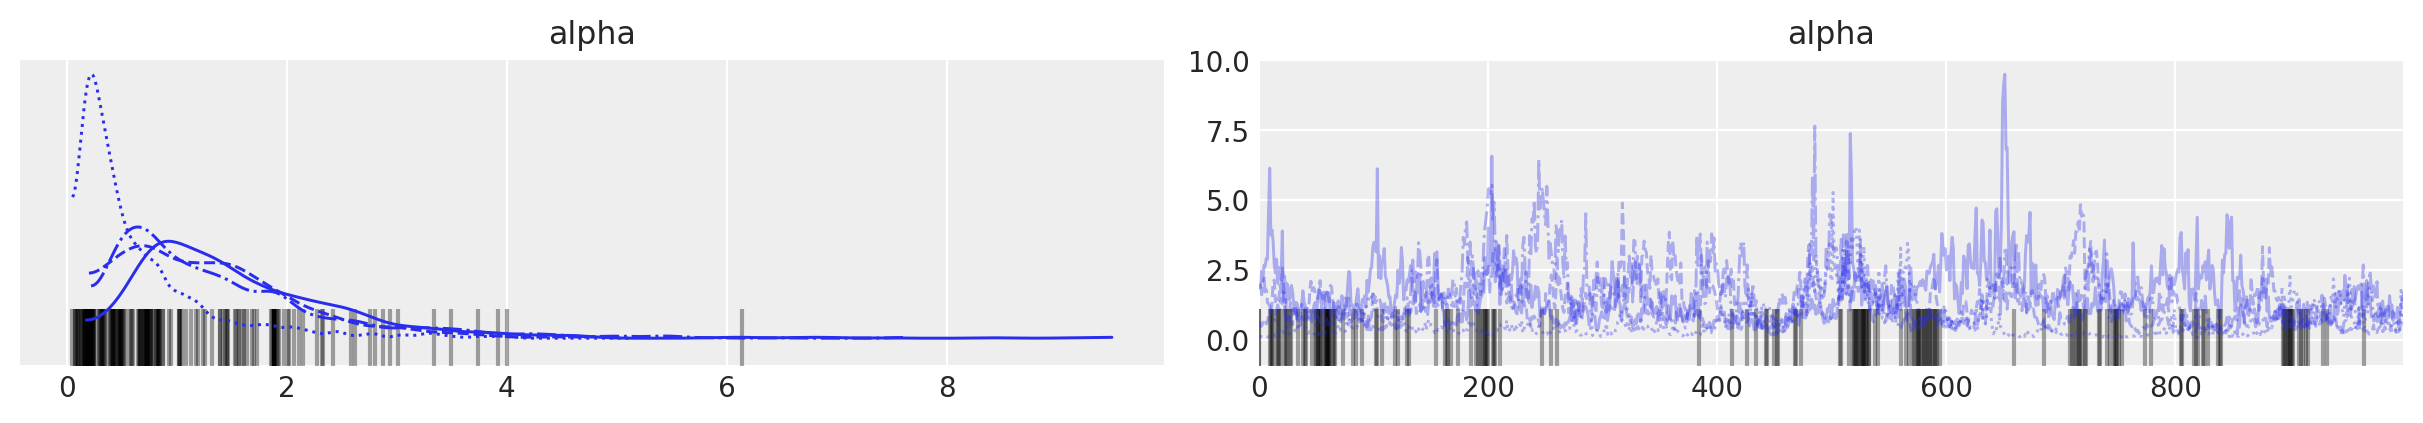

In [93]:
az.plot_trace(trace, var_names=["alpha"]);

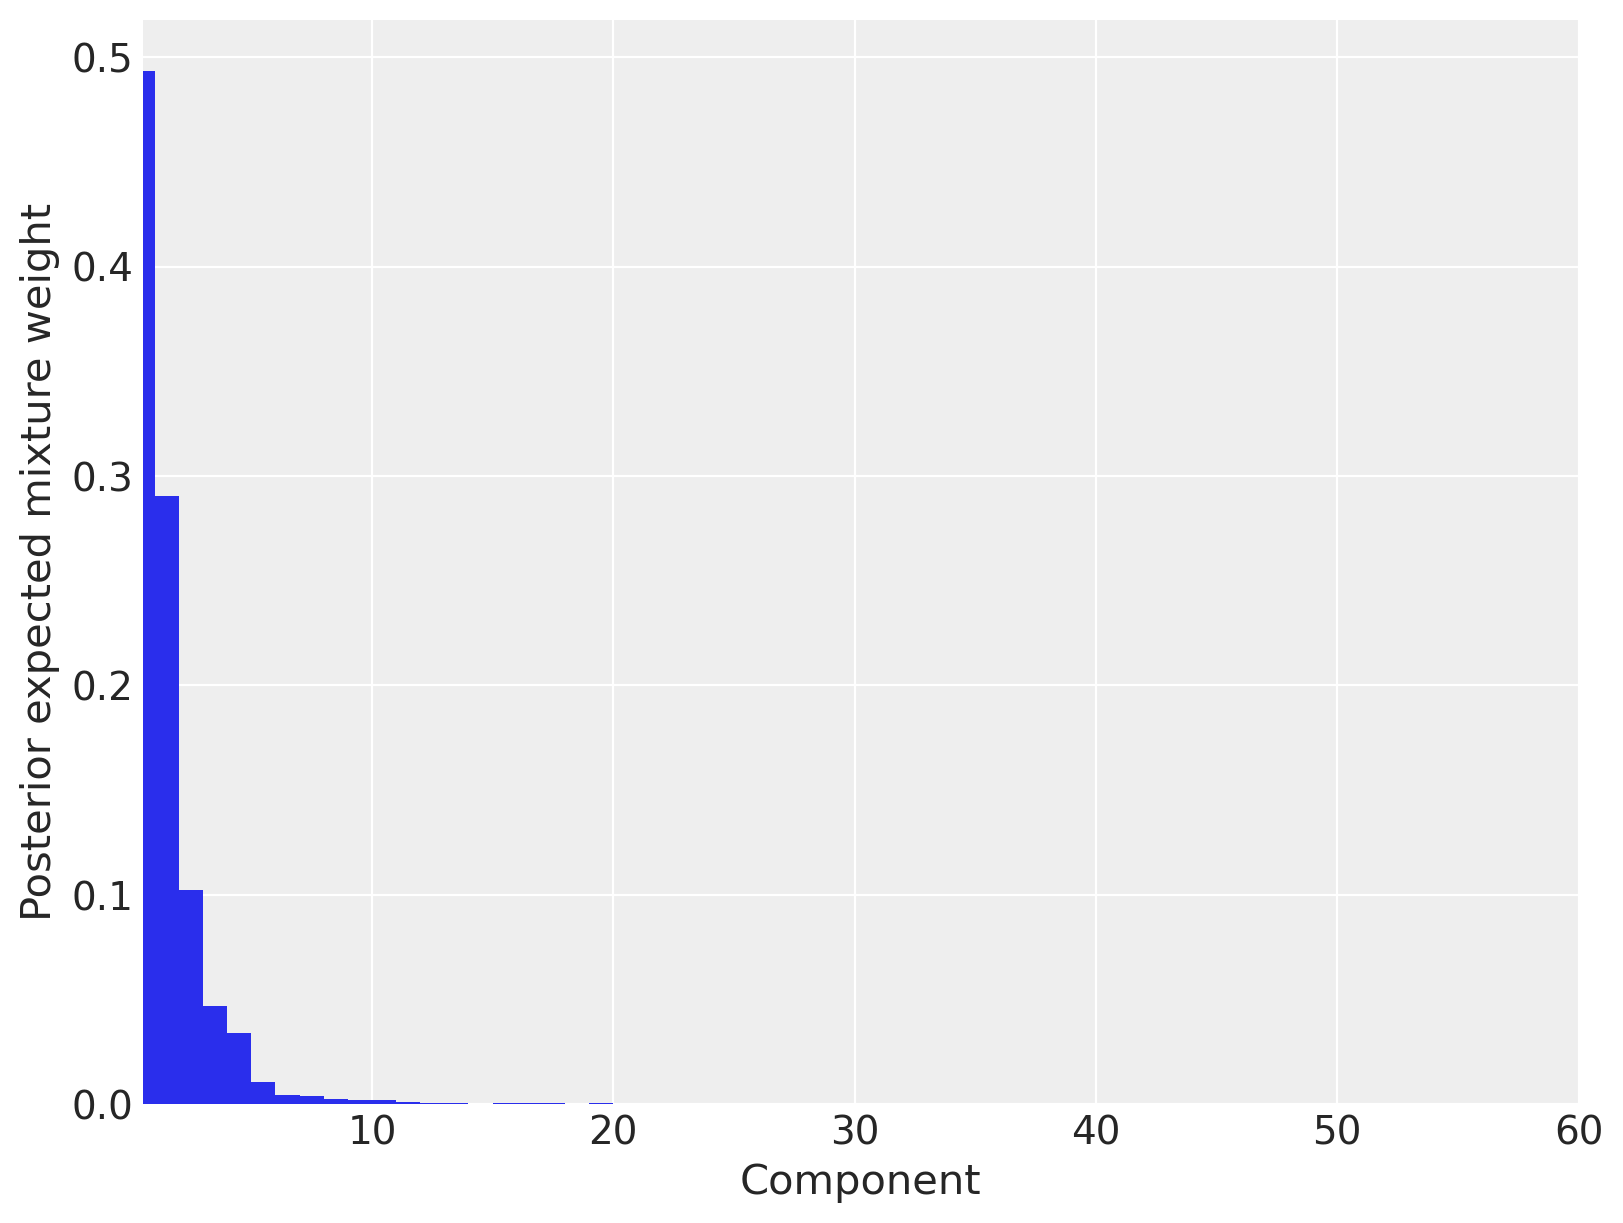

In [94]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_w = np.arange(K) + 1

ax.bar(plot_w - 0.5, trace.posterior["w"].mean(("chain", "draw")), width=1.0, lw=0)

ax.set_xlim(0.5, K)
ax.set_xlabel("Component")

ax.set_ylabel("Posterior expected mixture weight");

In [95]:
post_pdf_contribs = xr.apply_ufunc(
    sp.stats.norm.pdf,
    x_plot,
    trace.posterior["mu"],
    1.0 / np.sqrt(trace.posterior["lambda_"] * trace.posterior["tau"]),
)

post_pdfs = (trace.posterior["w"] * post_pdf_contribs).sum(dim=("component"))

post_pdf_quantiles = post_pdfs.quantile([0.1, 0.9], dim=("chain", "draw"))

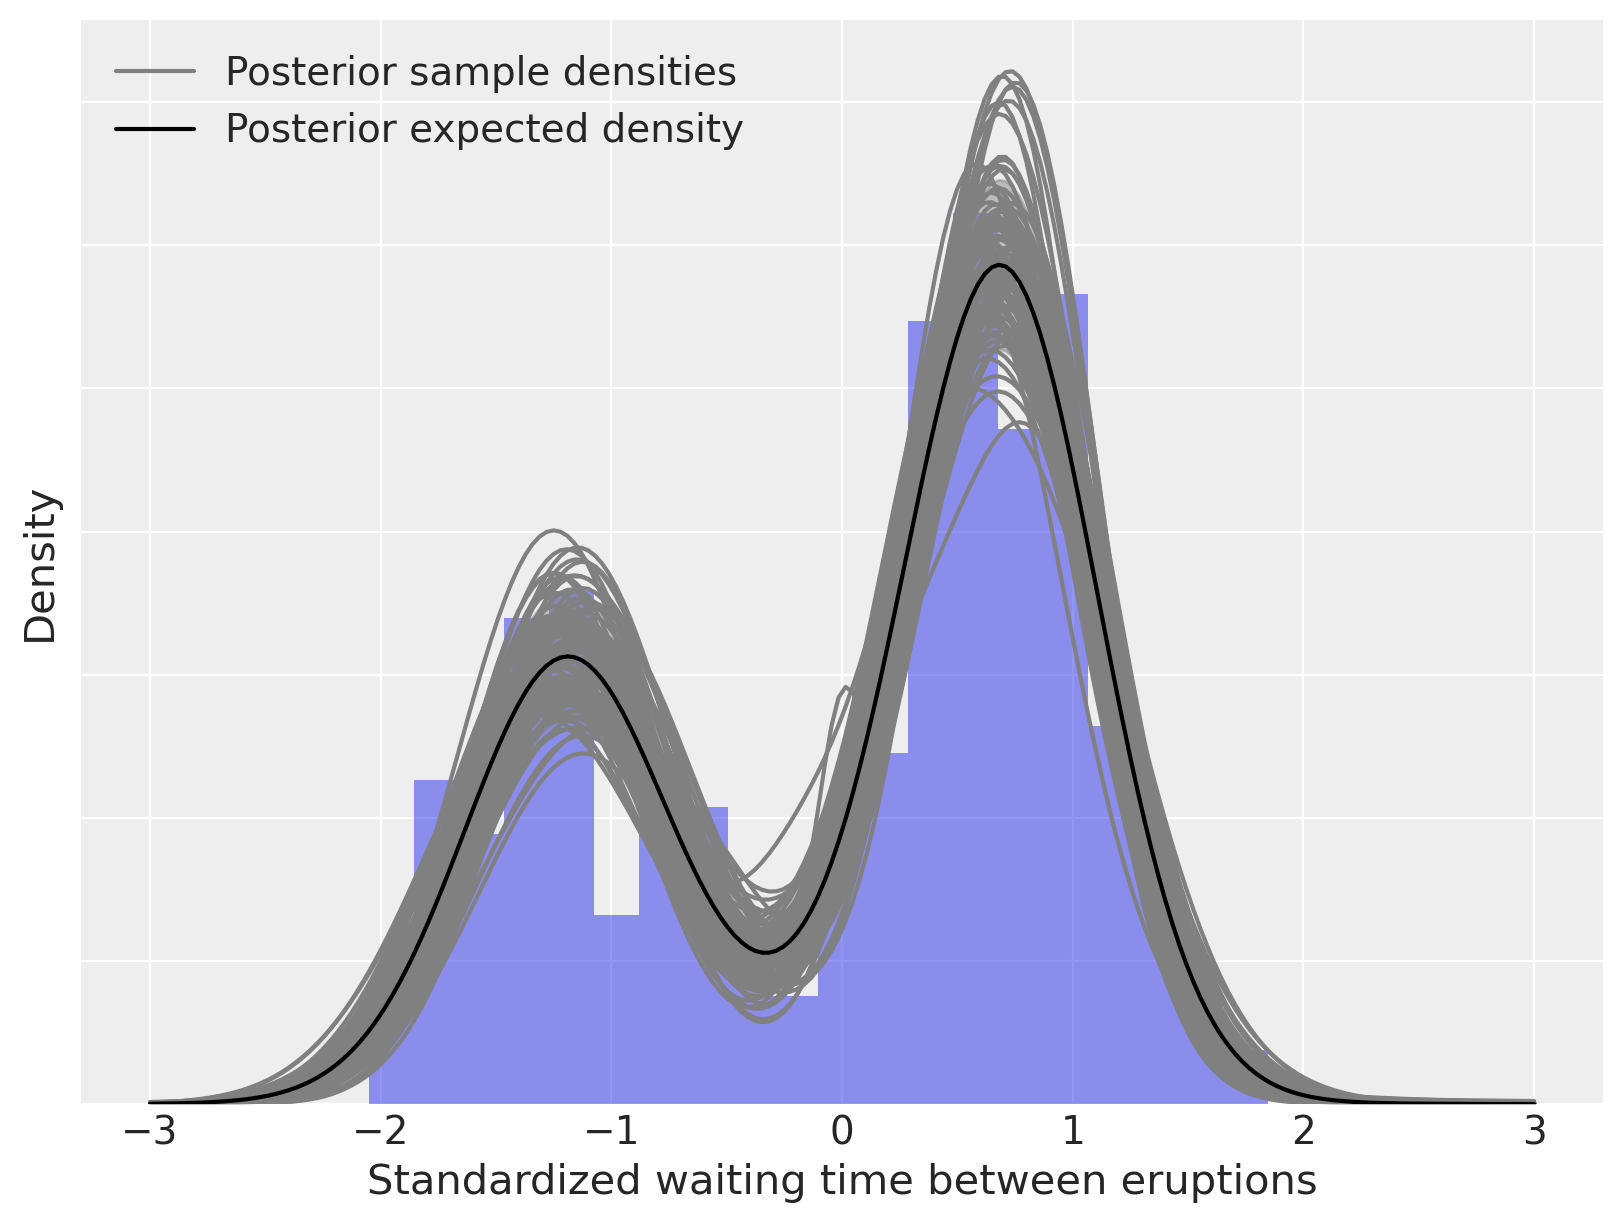

In [96]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.fill_between(
    x_plot,
    post_pdf_quantiles.sel(quantile=0.1),
    post_pdf_quantiles.sel(quantile=0.9),
    color="gray",
    alpha=0.45,
)
ax.plot(x_plot, post_pdfs.sel(chain=0, draw=0), c="gray", label="Posterior sample densities")
ax.plot(
    x_plot,
    az.extract(post_pdfs, var_names="x", num_samples=100),
    c="gray",
)
ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

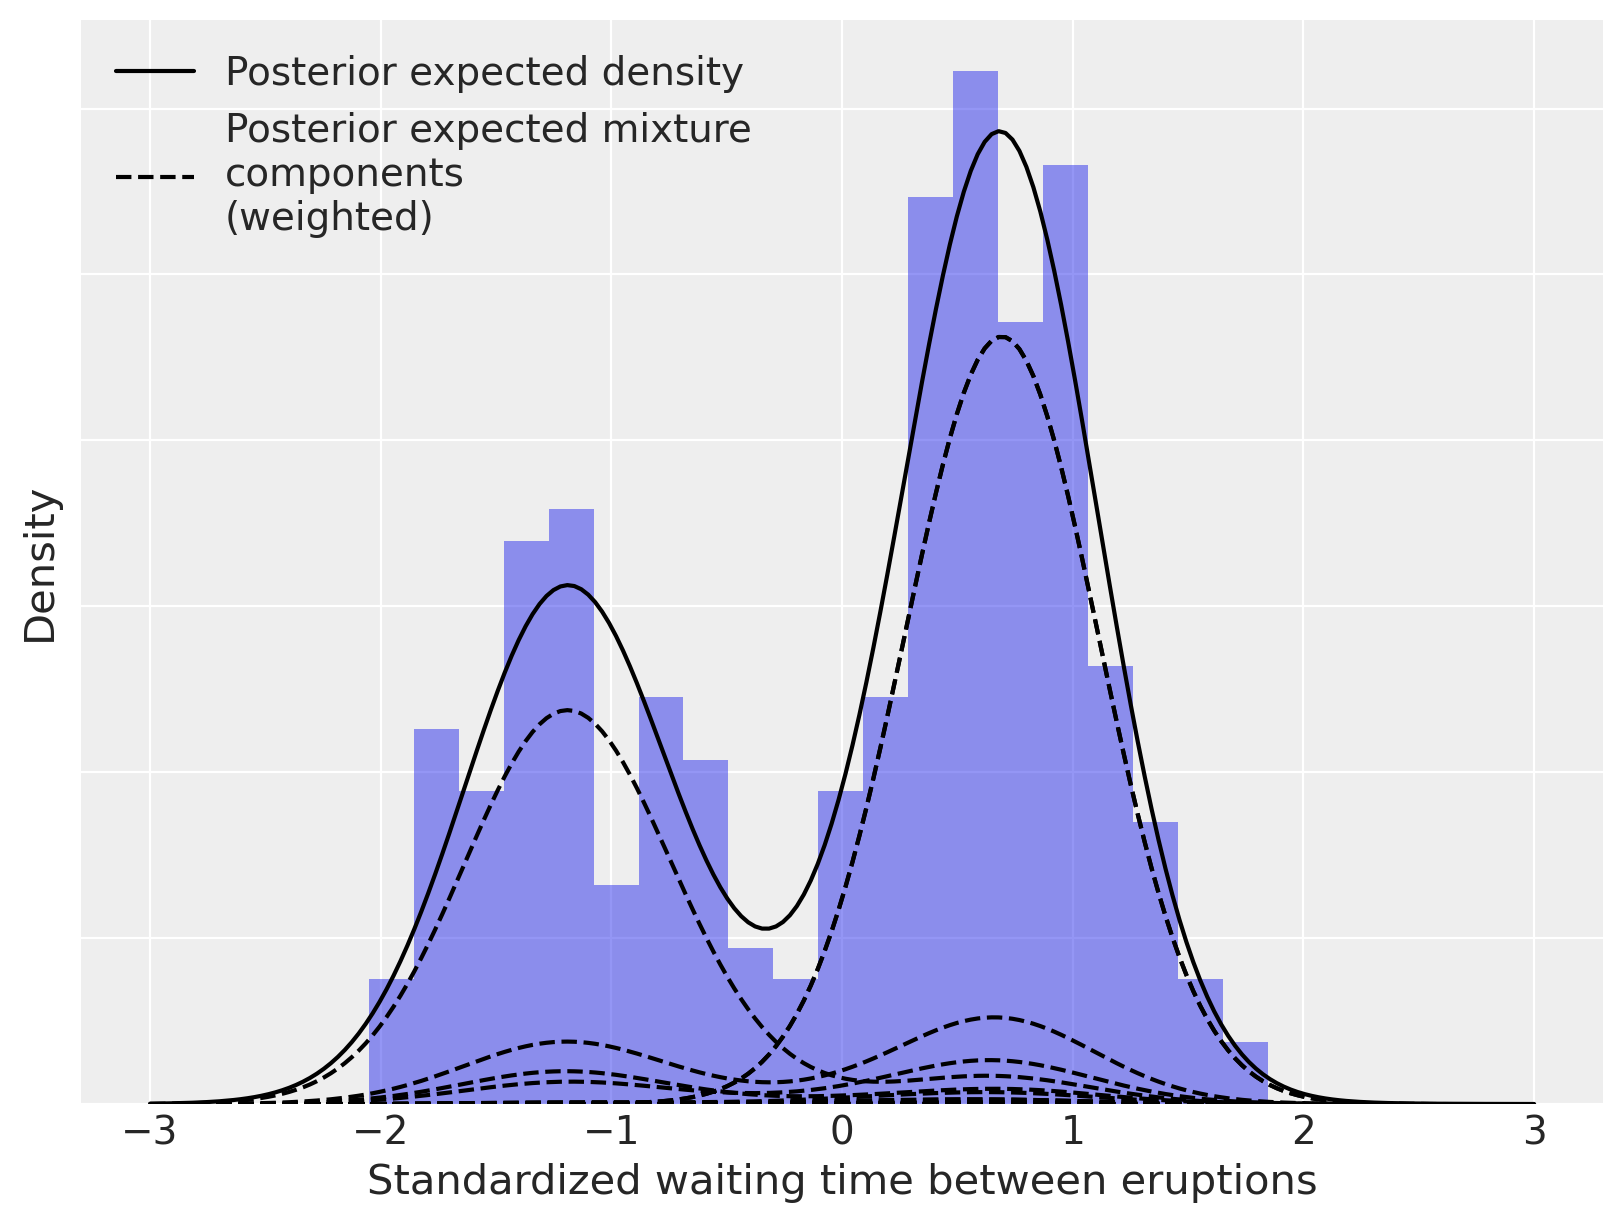

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).sel(component=0),
    "--",
    c="k",
    label="Posterior expected mixture\ncomponents\n(weighted)",
)
ax.plot(
    x_plot,
    (trace.posterior["w"] * post_pdf_contribs).mean(dim=("chain", "draw")).T,
    "--",
    c="k",
)

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

In [100]:
J = 5      # Number of groups
K = 20     # Truncation level
alpha = 1.0
gamma = 1.0
RANDOM_SEED = 42

coords = {
    "component": np.arange(K),
    "group": np.arange(J),
    "obs_id": np.arange(N),
}

with pm.Model(coords=coords) as hdp_model:
    # Global base stick-breaking weights
    v = pm.Beta("v", 1, gamma, dims="component")
    beta = pm.Deterministic("beta", stick_breaking(v), dims="component")

    # Group-specific stick-breaking weights
    pi = pm.Dirichlet("pi", a=alpha * beta, dims=("group", "component"))

    # Component parameters (example: Gaussian with known dimension)
    mu = pm.Normal("mu", mu=0, sigma=5, dims=("component"))
    sigma = pm.HalfNormal("sigma", sigma=1.0, dims=("component"))

    # Latent assignments
    z = pm.Categorical("z", p=pi, dims="group")

    # Observations: dummy placeholder
    obs = pm.NormalMixture(
        "obs", w, mu, sigma=sigma, observed=old_faithful_df.std_waiting.values, dims="obs_id"
    )

In [101]:
with hdp_model:
    trace = pm.sample(
        tune=2500,
        init="advi",
        target_accept=0.975,
        random_seed=RANDOM_SEED,
    )

ValueError: Random variables detected in the logp graph: {MeasurableMul.0, MeasurableAdd.0, beta, beta_0, MeasurableCumsum{0, add}.0, alpha_lifted, alpha_0_lifted, MeasurableMul.0, MeasurableAdd.0}.
This can happen when DensityDist logp or Interval transform functions reference nonlocal variables,
or when not all rvs have a corresponding value variable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.distributions import constraints

import pyro
from pyro.distributions import *
from pyro.infer import Predictive, SVI, Trace_ELBO
from pyro.optim import Adam

assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(0)

In [2]:
def mix_weights(beta):
    beta1m_cumprod = (1 - beta).cumprod(-1)
    return F.pad(beta, (0, 1), value=1) * F.pad(beta1m_cumprod, (1, 0), value=1)

In [3]:
def model(data, alpha, gamma, eta, T, S, N):
    with pyro.plate("rho_plate", S-1):
        rho = pyro.sample("rho", Beta(1, eta))
    
    with pyro.plate("beta_plate", T-1):
        beta = pyro.sample("beta", Beta(1, alpha))

    with pyro.plate("weight_plate", S):
        w = pyro.sample("w", Dirichlet(gamma*mix_weights(beta)))
    
    with pyro.plate("mu_plate", T):
        mu = pyro.sample("mu", MultivariateNormal(torch.zeros(2), 5 * torch.eye(2)))

    with pyro.plate("data", N):
        c = pyro.sample("c", Categorical(mix_weights(rho)))
        z = pyro.sample("z", Categorical(w[c]))
        pyro.sample("obs", MultivariateNormal(mu[z], torch.eye(2)), obs=data)

In [17]:
def guide(data, alpha, gamma, eta, T, S, N):
    kappa = pyro.param('kappa', lambda: Uniform(0, 2).sample([T-1]), constraint=constraints.positive)
    omega = pyro.param('omega', lambda: Uniform(0, 2).sample([S-1]), constraint=constraints.positive)
    psi = pyro.param('psi', lambda: Uniform(0, 2).sample([T]), constraint=constraints.positive)
    tau = pyro.param('tau', lambda: MultivariateNormal(torch.zeros(2), 3 * torch.eye(2)).sample([T]))
    phi = pyro.param('phi', lambda: Dirichlet(1/T * torch.ones(T)).sample([S]), constraint=constraints.simplex)
    nu = pyro.param('nu', lambda: Dirichlet(1/S * torch.ones(S)).sample([N]), constraint=constraints.simplex)
    
    with pyro.plate("rho_plate", S-1):
        q_rho = pyro.sample("rho", Beta(torch.ones(S-1), omega))
        
    with pyro.plate("beta_plate", T-1):
        q_beta = pyro.sample("beta", Beta(torch.ones(T-1), kappa))

    with pyro.plate("weight_plate", S):
        q_w = pyro.sample("w", Dirichlet(psi))

    with pyro.plate("mu_plate", T):
        q_mu = pyro.sample("mu", MultivariateNormal(tau, torch.eye(2)))

    with pyro.plate("data", N):
        c = pyro.sample("c", Categorical(nu))
        z = pyro.sample("z", Categorical(phi[c]))

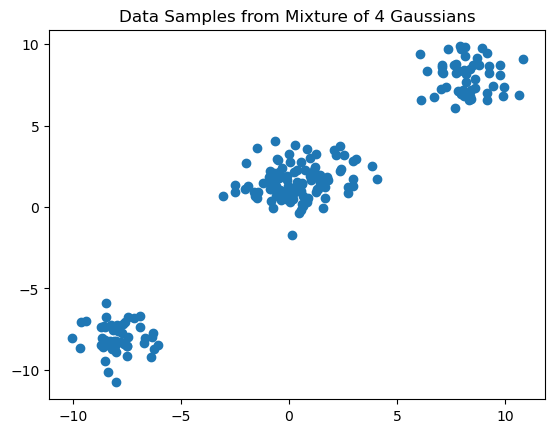

In [18]:
data = torch.cat((MultivariateNormal(-8 * torch.ones(2), torch.eye(2)).sample([50]),
                  MultivariateNormal(8 * torch.ones(2), torch.eye(2)).sample([50]),
                  MultivariateNormal(torch.tensor([1.5, 2]), torch.eye(2)).sample([50]),
                  MultivariateNormal(torch.tensor([-0.5, 1]), torch.eye(2)).sample([50])))

plt.scatter(data[:, 0], data[:, 1])
plt.title("Data Samples from Mixture of 4 Gaussians")
plt.show()
N = data.shape[0]


100%|███████████████████████████████████████| 1000/1000 [00:12<00:00, 82.84it/s]


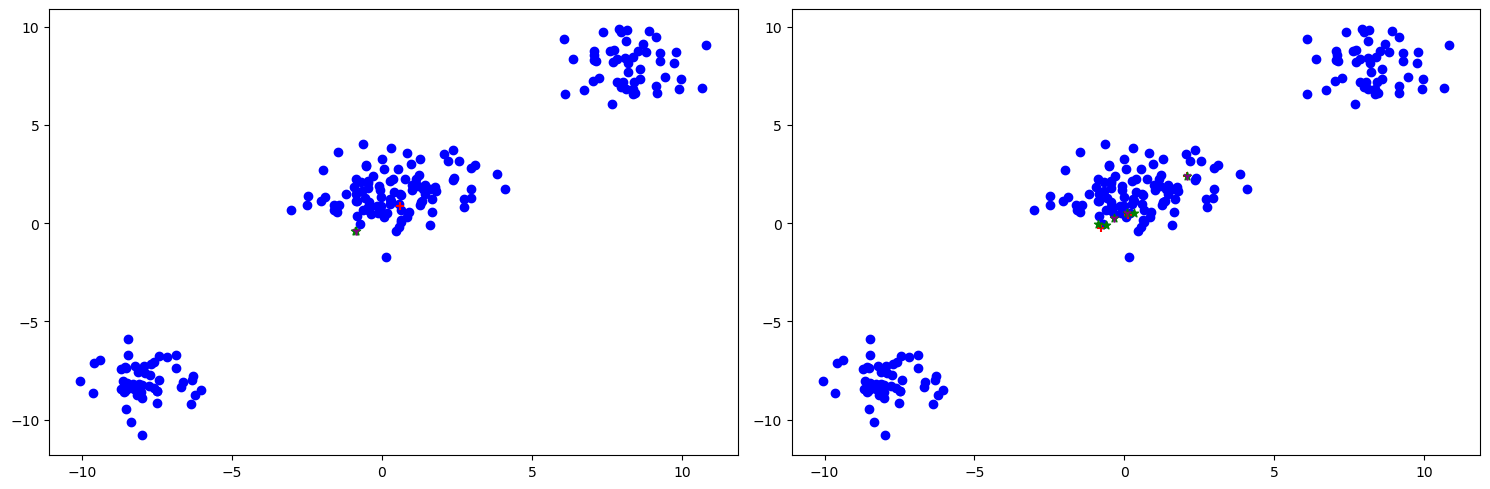

In [22]:
T = 10
S = 10
optim = Adam({"lr": 0.05})
svi = SVI(model, guide, optim, loss=Trace_ELBO())
losses = []

def train(num_iterations, alpha, gamma, eta, T, S, N):
    pyro.clear_param_store()
    for j in tqdm(range(num_iterations)):
        loss = svi.step(data, alpha, gamma, eta, T, S, N)
        losses.append(loss)

def truncate(alpha, centers, weights):
    threshold = alpha**-1 / 100.
    true_centers = []
    for weight in weights:
        true_centers.append(centers[weight > threshold])
    # true_centers = torch.cat(true_centers, dim=0)
    # # true_centers = centers[weights > threshold]
    true_weights = weights[weights > threshold] / torch.sum(weights[weights > threshold], dim=-1)
    return true_centers, true_weights

alpha = 0.1
gamma = 0.1
eta = 0.1
train(1000, alpha, gamma, eta, T, S, N)

# We make a point-estimate of our model parameters using the posterior means of tau and phi for the centers and weights
Bayes_Centers_01, Bayes_Weights_01 = truncate(alpha, pyro.param("tau").detach(), pyro.param("phi").detach())
Bayes_Category_01 = pyro.param("nu").detach()

alpha = 1.5
gamma = 1.5
eta = 1.5
train(1000, alpha, gamma, eta, T, S, N)

# We make a point-estimate of our model parameters using the posterior means of tau and phi for the centers and weights
Bayes_Centers_15, Bayes_Weights_15 = truncate(alpha, pyro.param("tau").detach(), pyro.param("phi").detach())
Bayes_Category_15 = pyro.param("nu").detach()

colors = ["red", "green", "purple"]
shapes = ["+", "*", "1"]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], color="blue")
for center, color, shape in zip(Bayes_Centers_01, colors, shapes):
    plt.scatter(center[:, 0], center[:, 1], color=color, marker=shape)
# plt.scatter(Bayes_Centers_01[:, 0], Bayes_Centers_01[:, 1], color="red")

plt.subplot(1, 2, 2)
plt.scatter(data[:, 0], data[:, 1], color="blue")
for center, color, shape in zip(Bayes_Centers_15, colors, shapes):
    plt.scatter(center[:, 0], center[:, 1], color=color, marker=shape)
# plt.scatter(Bayes_Centers_15[:, 0], Bayes_Centers_15[:, 1], color="red")
plt.tight_layout()
plt.show()



In [23]:
print("gaussian", pyro.param("tau").detach().shape)
print("weight", pyro.param("phi").detach().shape)
print("classification", pyro.param("nu").detach().shape)
print("category", pyro.param("psi").detach().shape)

gaussian torch.Size([10, 2])
weight torch.Size([10, 10])
classification torch.Size([200, 10])
category torch.Size([10])


In [28]:
print(set(list(torch.argmax(Bayes_Category_01, dim=1).numpy())))
print(set(list(torch.argmax(Bayes_Category_15, dim=1).numpy())))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [ ]:
df = pd.read_csv('http://www.sidc.be/silso/DATA/SN_y_tot_V2.0.csv', sep=';', names=['time', 'sunspot.year'], usecols=[0, 1])
data = torch.tensor(df['sunspot.year'].values, dtype=torch.float32).round()
N = data.shape[0]

plt.hist(df['sunspot.year'].values, bins=40)
plt.title("Number of Years vs. Sunspot Counts")
plt.xlabel("Sunspot Count")
plt.ylabel("Number of Years")
plt.show()